# TITANIC SURVIVAL ANALYSIS


In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Loading the dataset
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

print(df.head())          # Shows first 5 rows


Dataset loaded successfully!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [5]:
# Understanding the Dataset 
print("Shape of dataset (rows, columns):")
print(df.shape)           

print("\nColumn names in dataset:")
print(df.columns)

print("\nBasic information about dataset:")
print(df.info())


Shape of dataset (rows, columns):
(891, 12)

Column names in dataset:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Basic information about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usa

In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
#Handling missing values
mean_age = df['Age'].mean()
print("Mean Age: {:.2f}".format(mean_age))
df['Age'] = df['Age'].fillna(mean_age)

mode_embarked = df['Embarked'].mode()[0]
print("Most common Embarked value: ",format(mode_embarked))
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

df.drop(columns=['Cabin'], inplace=True, errors='ignore') 
print("\nCabin column dropped!")

print("\nMissing values AFTER handling:")
print(df.isnull().sum())


Mean Age: 29.70
Most common Embarked value:  S

Cabin column dropped!

Missing values AFTER handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [22]:
#Data analysis 
# Analysis 1: How many survived vs did not survive?
print("\nSurvival Count:")
print(df['Survived'].value_counts())


# Analysis 2: Survival by Gender
print("\nSurvival by Gender:")
print(df.groupby('Sex')['Survived'].value_counts())

# Analysis 3: Survival by Passenger Class
print("\nSurvival by Passenger Class:")
print(df.groupby('Pclass')['Survived'].value_counts())

#Analysis 4: Average age of Survivors vs non-survivors
print("\nAverage age of Survivors vs non-survivors ")
print(df.groupby('Survived')['Age'].mean())




Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival by Gender:
Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Survival by Passenger Class:
Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

Average age of Survivors vs non-survivors 
Survived
0    30.415100
1    28.549778
Name: Age, dtype: float64


In [49]:
# Survival rate by both class and gender together
combined = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
print(combined)


# Average fare paid by survivors vs non-survivors
print(df.groupby('Survived')['Fare'].mean())

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


# Data Visualization 

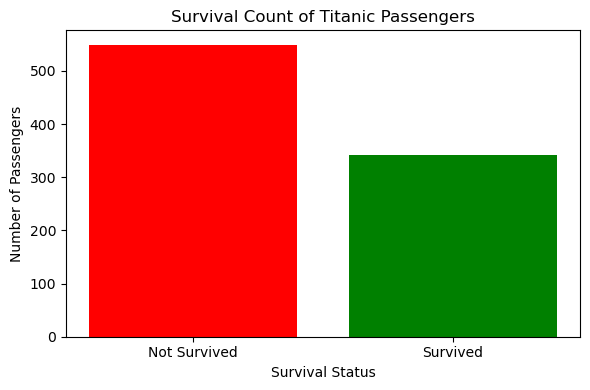

In [ ]:
# GRAPH 1: Bar Chart - Survival Count 
plt.figure(figsize=(6, 4))          # Set graph size
survival_counts = df['Survived'].value_counts()
plt.bar(['Not Survived', 'Survived'],  # X-axis labels
        survival_counts,               # Y-axis values
        color=['red', 'green'])        # Bar colors
plt.title('Survival Count of Titanic Passengers')  # Graph title
plt.xlabel('Survival Status')          
plt.ylabel('Number of Passengers')    
plt.tight_layout()
plt.show()




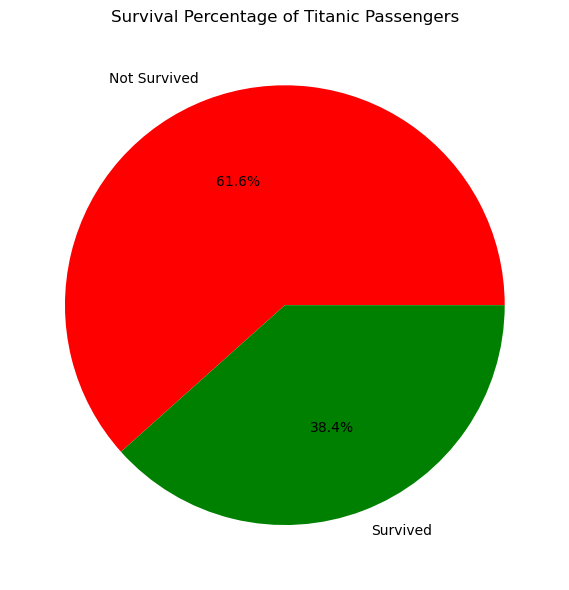

In [27]:
#GRAPH 2: Pie Chart - Survived vs Not Survived 
plt.figure(figsize=(6, 6))
plt.pie(survival_counts,
        labels=['Not Survived', 'Survived'],
        colors=['red', 'green'],
        autopct='%1.1f%%')    # Shows percentage on pie chart to 1 decimal point 
plt.title('Survival Percentage of Titanic Passengers')
plt.tight_layout()
plt.savefig('graph2_survival_pie.png')
plt.show()


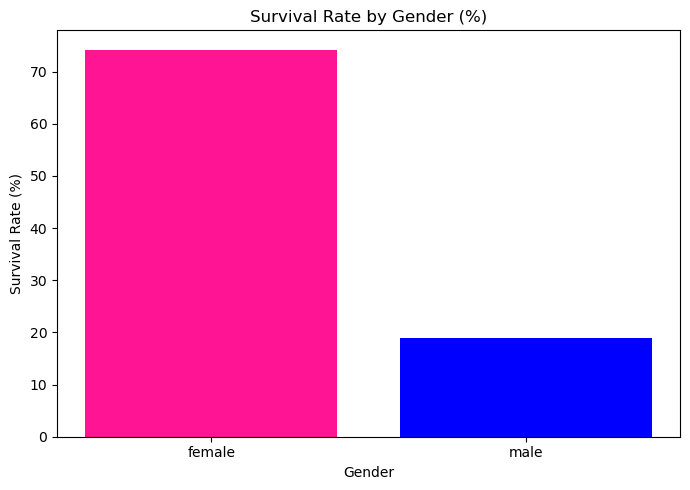

In [ ]:
#GRAPH 3: Bar Chart - Survival by Gender
plt.figure(figsize=(7, 5))
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
# .mean() gives survival rate, *100 converts to percentage
plt.bar(gender_survival.index,    
        color=['deeppink', 'blue'])
plt.title('Survival Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.savefig('graph3_gender_survival.png')
plt.show()


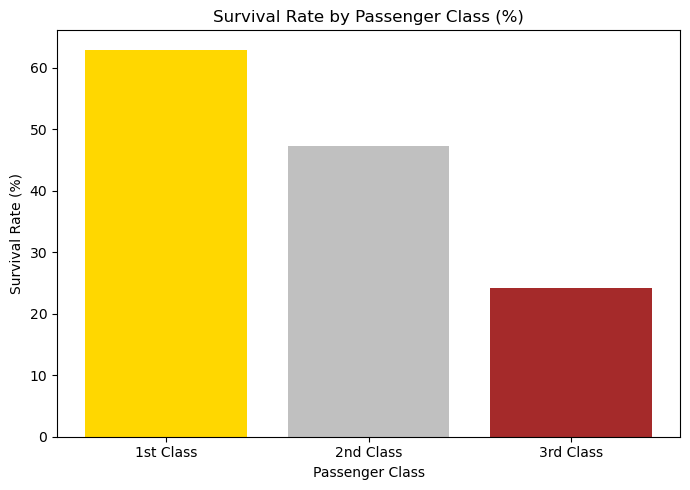

In [32]:
#GRAPH 4: Bar Chart - Survival by Passenger Class
plt.figure(figsize=(7, 5))
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
plt.bar(['1st Class', '2nd Class', '3rd Class'],
        class_survival.values,
        color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Passenger Class (%)')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.savefig('graph4_class_survival.png')
plt.show()

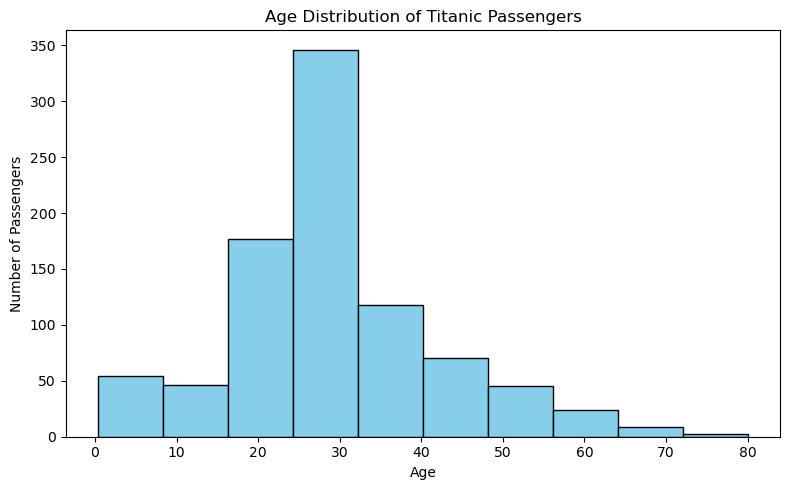

In [36]:
#GRAPH 5: Histogram - Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Age'],       # Data to plot
         bins=10,         # Number of bars in histogram
         color='skyblue',
         edgecolor='black')  
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.savefig('graph5_age_distribution.png')
plt.show()

<Figure size 600x400 with 0 Axes>

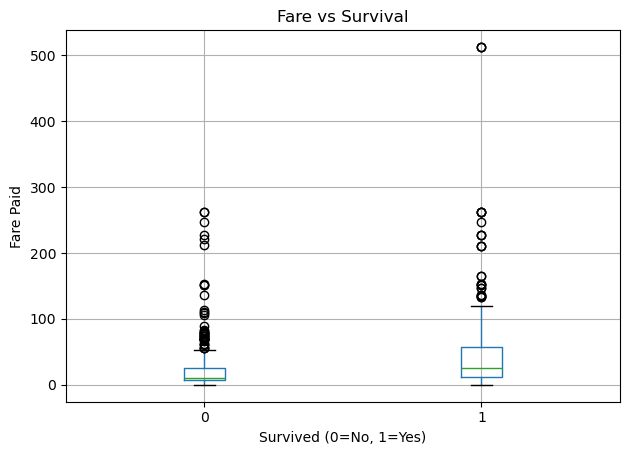

In [50]:

# Did people who paid more survive more?
plt.figure(figsize=(6,4))
df.boxplot(column='Fare', by='Survived')
plt.title('Fare vs Survival')
plt.suptitle('')  # Removes default title
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare Paid')
plt.tight_layout()
plt.show()
